In [1]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [3]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:01<00:00, 96.9MB/s] 


In [4]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [5]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [6]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


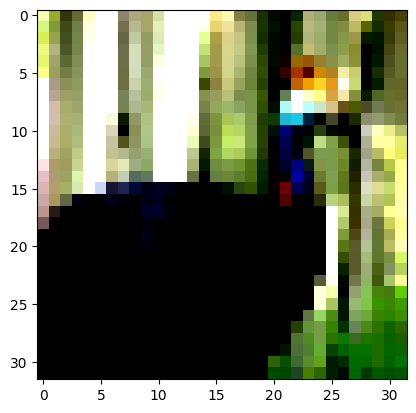

In [7]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [8]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [9]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [10]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 256,
    'test_size': 0.2
}

In [11]:
class Trainer:
    def __init__(self, config, transform=None, model=None):
        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f'Using device: {self.device}')
        self.model = model.to(self.device)
        

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.losses = {'train': [], 'val': [], 'test': []}
        self.accuracies = {'train': [], 'val': [], 'test': []}

        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            print(f"Epoch {epoch + 1} / {self.config['num_epochs']}", train_loss, val_loss, val_acc)

            self.losses['train'].append(train_loss)
            self.losses['val'].append(val_loss)

            self.accuracies['train'].append(train_acc)
            self.accuracies['val'].append(val_acc)


        test_loss, test_acc = self.test_step()
        self.accuracies['test'].append(test_acc)
        self.losses['test'].append(test_loss)
        print(f'Test loss {test_loss}, test acc {test_acc}')

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.val_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        return total_loss, val_acc

    def test_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.test_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100

        return total_loss, test_acc
    
    def plot_losses(self):
        plt.plot(self.losses['train'], label='train')
        plt.plot(self.losses['val'], label='val')
        plt.legend()
        plt.show()

        plt.plot(self.accuracies['train'], label='train')
        plt.plot(self.accuracies['val'], label='val')
        plt.legend()
        plt.show()

In [12]:
trainer_base = Trainer(config, transform=transform, model=BasicCNN())

Using device: cuda


In [13]:
trainer_base.run()

100%|██████████| 40/40 [00:02<00:00, 15.66it/s]


Epoch 1 / 10 1.6664650151684026 1.3895285874605179 49.059999999999995


100%|██████████| 40/40 [00:02<00:00, 15.69it/s]


Epoch 2 / 10 1.2938681203088942 1.2301348865032196 55.84


100%|██████████| 40/40 [00:02<00:00, 15.87it/s]


...

Epoch 9 / 10 0.7891990971413387 0.9980634987354279 65.56


100%|██████████| 40/40 [00:02<00:00, 15.85it/s]


Epoch 10 / 10 0.7738962701171826 1.0097025513648987 65.4


100%|██████████| 40/40 [00:02<00:00, 16.21it/s]

Test loss 1.0356799900531768, test acc 64.16


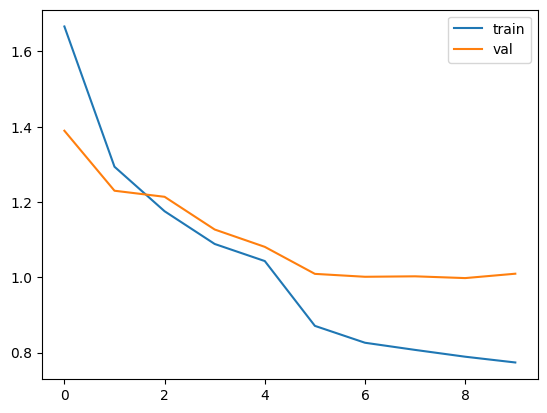

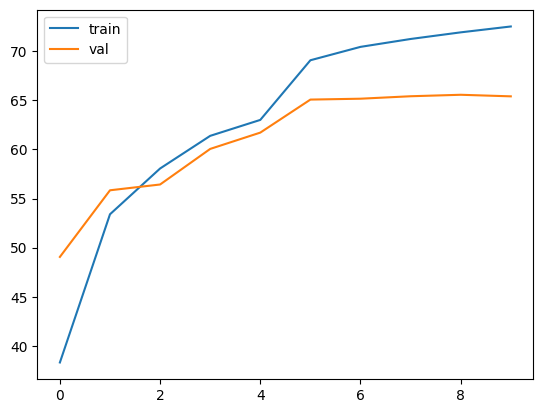

In [14]:
trainer_base.plot_losses()

# ResNet-18

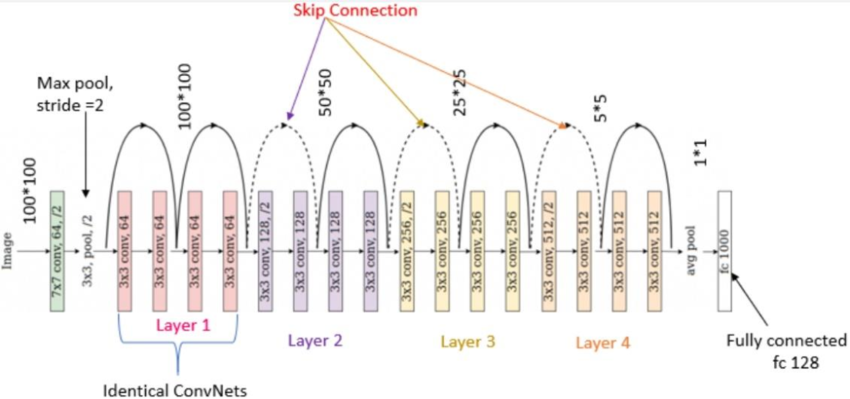

In [15]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        if self.downsample is not None:
            identity = self.downsample(identity)

        # Применить свертки + skip connection

        out =self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = F.relu(identity)

        return out# + identity

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Сделать 4 блока
        self.layer1 = self.make_layer(64, 2)
        self.layer2 = self.make_layer(128, 2)
        self.layer3 = self.make_layer(256, 2)
        self.layer4 = self.make_layer(512, 2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
        
        layers = nn.Sequential(ResNetBlock(self.in_channels, out_channels, stride, downsample),
                             ResNetBlock(out_channels, out_channels))
        self.in_channels = out_channels
        return layers
    

    def forward(self, x):

        # сделать forward pass
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

trainer2 = Trainer(config, transform=transform, model=ResNet18())

Using device: cuda


Запустить Trainer с ResNet18 на 10 эпох и сранивать графики train / val / test точности с базовой CNN

In [16]:
trainer2.run()

100%|██████████| 40/40 [00:03<00:00, 10.56it/s]


Epoch 1 / 10 1.6569946282988142 1.691517949104309 39.65


100%|██████████| 40/40 [00:03<00:00, 10.84it/s]


Epoch 2 / 10 1.3759475141573863 1.3194800212979316 51.5


100%|██████████| 40/40 [00:03<00:00, 10.83it/s]


...

Epoch 9 / 10 0.8587081367802468 0.9509108617901803 67.13


100%|██████████| 40/40 [00:03<00:00, 10.76it/s]


Epoch 10 / 10 0.8431174565272727 0.9544725298881531 66.79


100%|██████████| 40/40 [00:03<00:00, 10.76it/s]

Test loss 0.9539279267191887, test acc 66.46


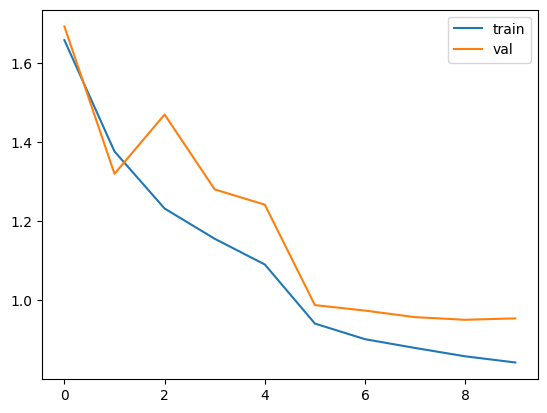

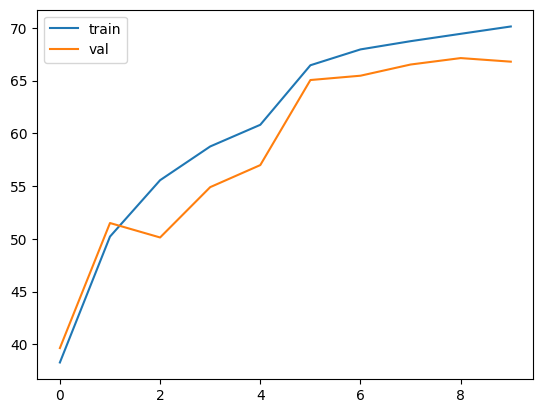

In [17]:
trainer2.plot_losses()

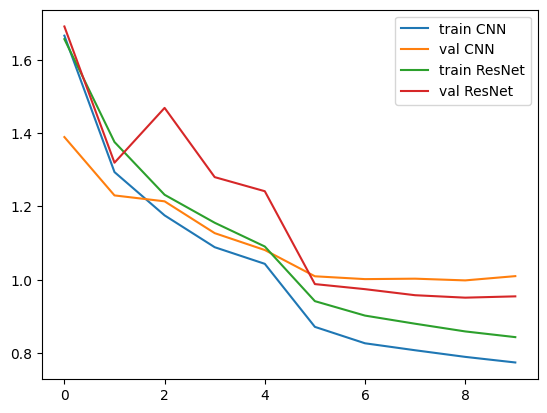

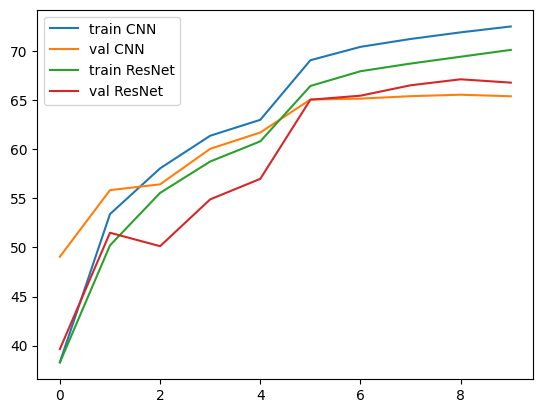

In [18]:
plt.plot(trainer_base.losses['train'], label='train CNN')
plt.plot(trainer_base.losses['val'], label='val CNN')
plt.plot(trainer2.losses['train'], label='train ResNet')
plt.plot(trainer2.losses['val'], label='val ResNet')
plt.legend()
plt.show()

plt.plot(trainer_base.accuracies['train'], label='train CNN')
plt.plot(trainer_base.accuracies['val'], label='val CNN')
plt.plot(trainer2.accuracies['train'], label='train ResNet')
plt.plot(trainer2.accuracies['val'], label='val ResNet')
plt.legend()
plt.show()

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

Ну, ResNet немного лучше